# Quantum Kernel for Biomedical Classification

Predicting real drug–disease treatment links with a quantum kernel, and finding
out whether it beats an RBF kernel. (Spoiler: it ties, and getting to a *trustworthy*
tie was most of the work.)

Companion to [`tutorials/04-qml/03-quantum-kernel-biomedical-classification.md`](../tutorials/04-qml/03-quantum-kernel-biomedical-classification.md).

**Requires:** `pip install -e ".[qiskit]"` and `python scripts/download_data.py` (~12 MB).

## 1. Real data, and why it matters

An earlier version of this tutorial used Gaussian blobs from `make_classification`
and concluded the quantum kernel loses. Blob geometry is close to *ideal* for an
RBF kernel, so that conclusion was an artifact of the data generator.

This uses [Hetionet](https://het.io) — 47k nodes, 2.25M edges, CC0 — and predicts
genuine `Compound–treats–Disease` edges.

In [1]:
from qprac_lab.data.hetionet import make_hetionet_link_prediction_dataset

dataset = make_hetionet_link_prediction_dataset(n_pairs=200)

print(f"source:    {dataset.metadata['source']}")
print(f"licence:   {dataset.metadata['license']}")
print(f"target:    {dataset.metadata['target_edge_type']}")
print(f"excluded:  {dataset.metadata['excluded_edge_types']}   <- label + near-label edges")
print(f"samples:   {len(dataset)} ({dataset.labels.mean():.0%} positive)")
print(f"features:  {list(dataset.feature_names)}")

source:    Hetionet v1.0 (Himmelstein et al., eLife 2017)
licence:   CC0 1.0 (public domain)
target:    CtD (Compound-treats-Disease)
excluded:  ['CtD', 'CpD']   <- label + near-label edges
samples:   200 (50% positive)
features:  ['bind_gene_overlap', 'any_gene_overlap', 'jaccard_gene', 'adamic_adar_gene']


## 2. Two ways this benchmark could have been rigged

**Label leakage.** Features use only compound–gene and gene–disease edges. The
`CtD` edge being predicted is never traversed, and neither is `CpD` (*palliates*),
which is close enough to *treats* to act as a label in disguise. Because no
feature path touches either, there is nothing to mask per split.

**A degree shortcut.** This is the subtler one. With random negatives, well-studied
compounds have both more edges *and* more known treatments — so a classifier scores
well knowing only "how famous is this drug". Negatives are instead degree-matched:
the disease is held fixed (exact degree match) and the substitute compound is drawn
from the 15 nearest by degree.

In [2]:
print(f"negative sampling: {dataset.metadata['negative_sampling']}")
print()
print(f"degree-only ROC-AUC: {dataset.metadata['degree_only_roc_auc']:.4f}"
      f"  ({dataset.metadata['degree_only_roc_auc_scope']})")
print("  ~0.5 means degree carries no shortcut. With uniform random negatives it is 0.689.")

negative sampling: degree-matched: disease held fixed, compound drawn from the 15 nearest by degree

degree-only ROC-AUC: 0.5376  (full dataset, before any subsampling)
  ~0.5 means degree carries no shortcut. With uniform random negatives it is 0.689.


The task got *harder* and the numbers got *worse*. That is what fixing a
benchmark looks like.

## 3. The quantum kernel

Encode each point into a quantum state and define similarity as the squared
overlap: `K(x, x') = |<phi(x')|phi(x)>|^2`. The quantum computer contributes a
**similarity measure, not a learner** — a classical SVM does the learning.

Scaling is not optional on real data. These features span three orders of
magnitude, and feature values become rotation *angles*, so raw values would wrap
the encoding many times over.

In [3]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print(f"{'feature':>20} {'min':>8} {'max':>8}")
for index, name in enumerate(dataset.feature_names):
    column = dataset.features[:, index]
    print(f"{name:>20} {column.min():>8.3f} {column.max():>8.3f}")

angles = MinMaxScaler(feature_range=(0.0, np.pi)).fit_transform(dataset.features)
print(f"\nafter scaling: [{angles.min():.3f}, {angles.max():.3f}]")

             feature      min      max
   bind_gene_overlap    0.000   12.000
    any_gene_overlap    0.000   76.000
        jaccard_gene    0.000    0.055
    adamic_adar_gene    0.000   21.658

after scaling: [0.000, 3.142]


## 4. Evaluation: one split will not do

At the sizes a quantum kernel can afford, a single train/test split is genuinely
uninformative — on 80 samples this data gave test ROC-AUC anywhere from 0.54 to
0.85 depending only on the split seed, wider than any gap between the models.

So: repeated stratified cross-validation. The quantum kernel makes that cheap —
the full `n x n` matrix is computed **once** and every fold reuses submatrices, so
20 evaluations cost the quantum time of one.

(Takes ~80 s: 19,900 circuit pairs.)

In [4]:
from qprac_lab.algorithms.qml.quantum_kernel_biomedical import (
    run_quantum_kernel_biomedical_tutorial,
)

result = run_quantum_kernel_biomedical_tutorial(n_pairs=200)

print(f"evaluation: {result.evaluation['scheme']} "
      f"{result.evaluation['n_splits']}x{result.evaluation['n_repeats']} "
      f"= {result.evaluation['n_evaluations']} folds")
print(f"feature map: {result.feature_map['name']}, {result.feature_map['num_qubits']} qubits, "
      f"depth {result.feature_map['circuit_depth']}")
print(f"circuit pairs: {result.notes['circuit_evaluations']}")

evaluation: RepeatedStratifiedKFold 5x4 = 20 folds
feature map: zz_feature_map, 4 qubits, depth 19
circuit pairs: 19900


In [5]:
print(f"{'rank':>4} {'model':>22} {'ROC-AUC':>18} {'F1':>7}")
for row in result.ranking:
    print(f"{row['rank']:>4} {row['model']:>22} "
          f"{row['roc_auc']:.3f} +- {row['roc_auc_std']:.3f} {row['f1']:>7.3f}")

rank                  model            ROC-AUC      F1
   1     quantum_kernel_svm 0.587 +- 0.096   0.506
   2                rbf_svm 0.577 +- 0.076   0.457
   3          random_forest 0.501 +- 0.075   0.469


The quantum kernel ranks first. **It has not won.**

Both models saw identical folds, so the fair comparison is paired — fold-to-fold
noise cancels.

In [6]:
comparison = result.quantum_vs_rbf
print(f"mean ROC-AUC difference:  {comparison['mean_roc_auc_difference']:+.4f}")
print(f"std of the difference:    {comparison['std_roc_auc_difference']:.4f}")
print(f"quantum wins:             {comparison['quantum_wins']}/{comparison['comparable_folds']} folds")
print(f"difference exceeds noise: {comparison['difference_exceeds_noise']}   <- the honest answer")

mean ROC-AUC difference:  +0.0100
std of the difference:    0.0858
quantum wins:             12/20 folds
difference exceeds noise: False   <- the honest answer


A +0.01 edge against a 0.09 spread, winning 12 of 20 folds. That is a
**statistical tie**, surfaced as a field so it cannot be dropped from a summary.

## 5. Alignment predicts this for free

Kernel-target alignment measures how well a kernel separates the classes *before*
any classifier is trained. It costs one matrix multiply — run it before committing
to a full comparison.

In [7]:
alignment = result.kernel_alignment
print(f"quantum kernel: {alignment['quantum_kernel']:.4f}")
print(f"RBF kernel:     {alignment['rbf_kernel']:.4f}")
print(f"quantum higher: {alignment['quantum_higher']}")
print("\nOn the old blob data this was reversed (0.091 vs 0.136) and correctly")
print("predicted an RBF win. It has now flipped along with the outcome.")

quantum kernel: 0.0266
RBF kernel:     0.0101
quantum higher: True

On the old blob data this was reversed (0.091 vs 0.136) and correctly
predicted an RBF win. It has now flipped along with the outcome.


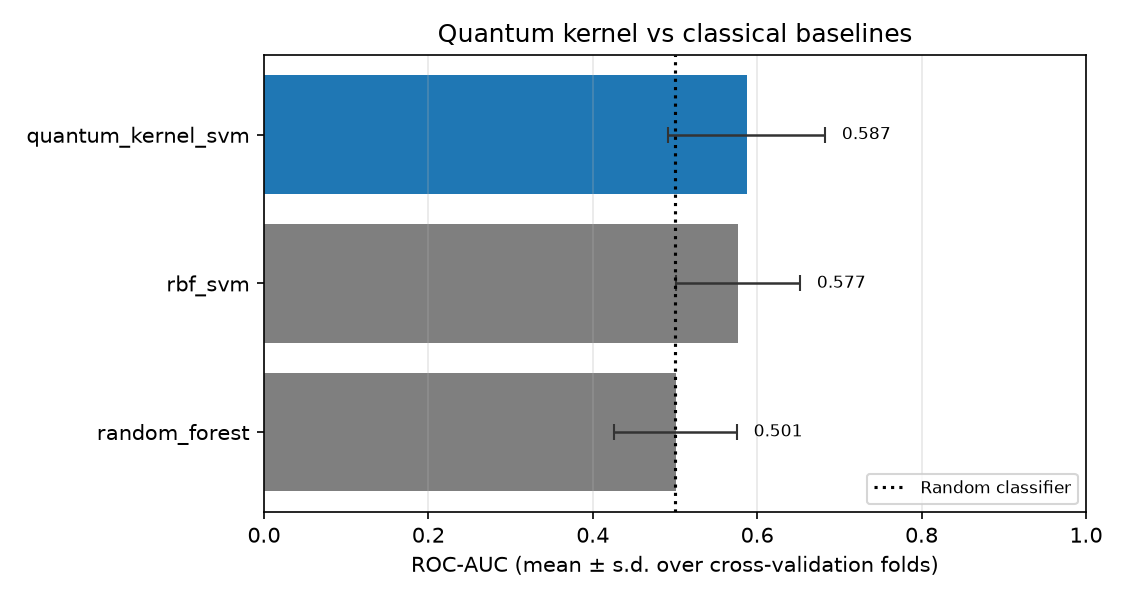

In [8]:
from qprac_lab.visualization.tutorial_outputs import plot_model_comparison
from IPython.display import Image

Image(plot_model_comparison(result.ranking, output_path="../results/nb_kernel_models.png"))

The error bars are the point: both intervals overlap, and both barely clear the
random-classifier line.

## 6. The cost

In [9]:
runtime = result.runtime_seconds
print(f"quantum kernel matrix:      {runtime['quantum_kernel_matrix']:.1f} s")
print(f"all 20 folds, all 3 models: {runtime['classical_models_total']:.2f} s")
print(f"overhead:                   {runtime['quantum_overhead_factor']:.0f}x")
print("\nand that is flattering: one kernel computation against 20 full classical fits.")

quantum kernel matrix:      74.0 s
all 20 folds, all 3 models: 1.96 s
overhead:                   38x

and that is flattering: one kernel computation against 20 full classical fits.


## 7. Self-fidelity: free noise diagnostics

`K(x, x)` is 1 by definition, so measuring it reads out exactly how much of the
circuit survived. Note that `FidelityQuantumKernel` **assumes** this diagonal by
default (`evaluate_duplicates="off_diagonal"`) rather than measuring it — free on
an ideal simulator, misleading under noise.

In [10]:
from qprac_lab.algorithms.qml.quantum_kernel_biomedical import measure_self_fidelity

sample = angles[:8]
print(f"{'noise':>10} {'self-fidelity':>15} {'min eigenvalue':>16}")
for noise in ["light", "moderate", "heavy"]:
    measured = measure_self_fidelity(sample, embedding_dim=4, noise=noise, shots=2048)
    print(f"{noise:>10} {measured['mean_self_fidelity']:>15.4f} "
          f"{measured['min_eigenvalue_without_psd_projection']:>+16.4f}")

     noise   self-fidelity   min eigenvalue


     light          0.9395          +0.0981


  moderate          0.7429          +0.0778


     heavy          0.3926          +0.0244


At heavy noise the compute–uncompute circuit has lost 61% of its fidelity, and
the negative minimum eigenvalue means the measured matrix is **not a valid
kernel** — `enforce_psd=True` is silently repairing it.

## When not to use this

- **Beyond a few hundred points.** Quadratic circuit cost, no approximation.
- **Without checking alignment first.** One matrix multiply.
- **Without repeated evaluation.** A single split cannot resolve a 0.01 difference.
- **Expecting an advantage.** There is still no demonstrated quantum-kernel
  advantage on practical data, and a tie on 200 samples is not one.